In [8]:
import time



class TimerDecorator:
    def __init__(self, func=None, *, print_each_call=False): #wszystkie argumenty po * muszą być podane jako nazwane
        self.func = func
        self.print_each_call = print_each_call
        self.times = []


#args to argumenty pozycyjne, kwargs to argumenty nazwane
    def __call__(self, *args, **kwargs):
         #__call__(*args, **kwargs) znaczy że dekorator może być używany z argumentami, rozpakowuje argumenty do wywołania funkcji
        if self.func is None and len(args) == 1 and callable(args[0]) and not kwargs:
            return type(self)(args[0], print_each_call=self.print_each_call)
        start = time.perf_counter()
        result = self.func(*args, **kwargs)
        end = time.perf_counter()

        duration = end - start
        self.times.append(duration)

        if self.print_each_call:
            print(f"[{self.func.__name__}] czas: {duration:.6f}s")

        return result

    def stats(self):
        if not self.times:
            return {
                "function": self.func.__name__,
                "calls": 0,
                "min": None,
                "max": None,
                "avg": None
            }

        return {
            "function": self.func.__name__,
            "calls": len(self.times),
            "min": min(self.times),
            "max": max(self.times),
            "avg": sum(self.times) / len(self.times)
        }

    def print_stats(self):
        s = self.stats() #fajne do przechowywania statystyk w jednej zmiennej
        print("staty")
        print(f"Funkcja: {s['function']}")
        print(f"Wywołania: {s['calls']}")
        print(f"Min czas: {s['min']:.6f}s")
        print(f"Max czas: {s['max']:.6f}s")
        print(f"Średni czas: {s['avg']:.6f}s")


# test

@TimerDecorator(print_each_call=True)
def slow_function(n):#funkcja do lulania o n sekund
    time.sleep(n)
    return n


@TimerDecorator(print_each_call=True)
def add(a, b):#funkcja do dodawania dwóch liczb
    return a + b


# testy
slow_function(0.2)
slow_function(0.3)
add(7000, 6857302)
add(10, 20)

# statystyki
slow_function.print_stats()
add.print_stats()

[slow_function] czas: 0.200204s
[slow_function] czas: 0.300227s
[add] czas: 0.000002s
[add] czas: 0.000001s
staty
Funkcja: slow_function
Wywołania: 2
Min czas: 0.200204s
Max czas: 0.300227s
Średni czas: 0.250215s
staty
Funkcja: add
Wywołania: 2
Min czas: 0.000001s
Max czas: 0.000002s
Średni czas: 0.000001s


In [5]:

class Temperature:
    def __init__(self, celsius):
        self.celsius = celsius

    @property
    def celsius(self):
        return self._celsius
    
    @property
    def kelvin(self):
        return self._celsius + 273.15
    
    @property
    def fahrenheit(self):
        return self._celsius * 9 / 5 + 32
    
    def _set_from_celsius(self, value):
        if value < -273.15:
            value = -273.15
        self._celsius = value

    @celsius.setter
    def celsius(self, value):
        self._set_from_celsius(value)


    @fahrenheit.setter
    def fahrenheit(self, value):
        c = (value - 32) * 5 / 9
        self._set_from_celsius(c)


    @kelvin.setter
    def kelvin(self, value):
        c = value - 273.15
        self._set_from_celsius(c)



    @property
    def is_freezing(self):
        return self._celsius <= 0

    @property
    def is_boiling(self):
        return self._celsius >= 100

    @property
    def state(self):
        if self._celsius < 0:
            return "solid"
        elif self._celsius < 100:
            return "liquid"
        return "gas"


    def __repr__(self):
        return f"Temperature({self._celsius:.2f}°C)"
    

t = Temperature(25)

print(t.celsius)      # 25
print(t.fahrenheit)   # 77.0
print(t.kelvin)       # 298.15

t.fahrenheit = 32
print(t.celsius)      # 0.0

t.kelvin = 300
print(t.celsius)      # 26.85

t.kelvin = -300      
print(t.kelvin) 
print(t.state)
print(t.is_freezing)
print(t.is_boiling)   # False

25
77.0
298.15
0.0
26.850000000000023
0.0
solid
True
False


In [18]:
import matplotlib.pyplot as plt
def lcg(seed, a, c, m, N):
    x = seed
    for _ in range(N):
        x = (a * x + c) % m
        yield x
        

# test

gen = lcg(1, 5, 3, 16, 5)

print(next(gen))
print(next(gen))

print("for:")
for val in lcg(1, 5, 3, 16, 5):
    print(val)


8
11
for:
8
11
10
5
12


Text(0.5, 1.0, 'Mogło być gorzej')

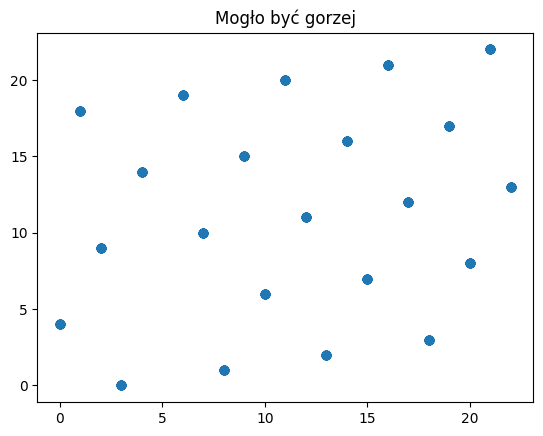

In [6]:
import matplotlib.pyplot as plt
def lcg(seed, a, c, m, N):
    x = seed
    for _ in range(N):
        val = x
        x = (a * x + c) % m
        yield x, val
        

# test
x1 = []
val1 = []
for x, val in lcg(9, 5, 3, 23, 500):
    x1.append(x)
    val1.append(val)

plt.scatter(x1, val1)
plt.title("Mogło być gorzej")